# 01picV2 — Lettuce Feature Extraction (with Plant Mask)

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew

## Cell 2 — โหลดภาพ + Segmentation (ตัดพื้นหลัง)

ขนาดภาพ : (480, 640, 3)
Plant pixels : 60,921 / 307,200 (19.8%)


C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\1358888104.py:25: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\1358888104.py:25: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\1358888104.py:25: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\1358888104.py:25: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\1358888104.py:25: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\135888810

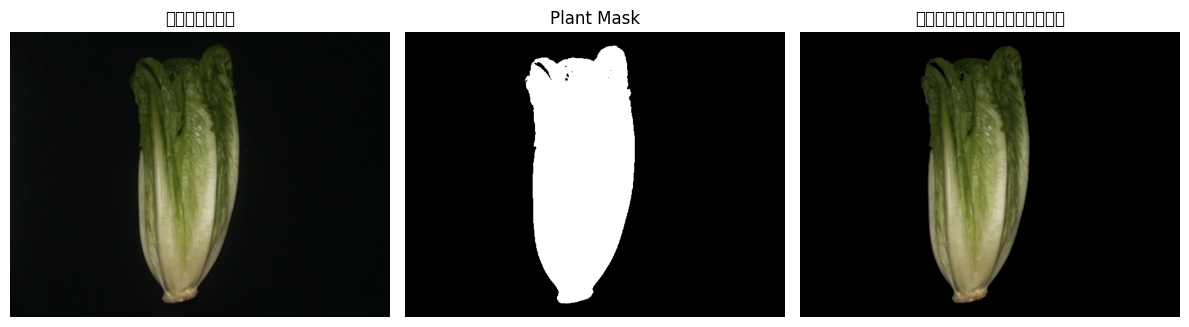

In [8]:
path = r"C:\For-Grading\data\cos\COS01_A_D0_E_top.jpg"
img_bgr = cv2.imread(path)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

# แยก channel ทุกอัน
b, g, r = cv2.split(img_bgr)
h, s, v = cv2.split(img_hsv)
l, a, b_ch = cv2.split(img_lab)

# Plant Mask — พื้นหลังดำ → V < 30 คือพื้นหลัง
_, plant_mask = cv2.threshold(v, 30, 255, cv2.THRESH_BINARY)
px = plant_mask > 0   # boolean index สำหรับใช้กับ numpy

print(f"ขนาดภาพ : {img_bgr.shape}")
print(f"Plant pixels : {np.sum(px):,} / {img_bgr.shape[0]*img_bgr.shape[1]:,} "
      f"({np.sum(px)/img_bgr.size*3*100:.1f}%)")

# แสดงภาพ + mask
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("ต้นฉบับ"); axes[0].axis("off")
axes[1].imshow(plant_mask, cmap="gray");                   axes[1].set_title("Plant Mask"); axes[1].axis("off")
masked = cv2.bitwise_and(img_bgr, img_bgr, mask=plant_mask)
axes[2].imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB));   axes[2].set_title("ตัดพื้นหลังแล้ว"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## Cell 2.5 — Illumination Normalization (Gray-world + CLAHE)
> รันก่อน Cell 3 เสมอ — feature ทั้งหมดจะคำนวณบน `img_norm` แทน `img_bgr`

Gray-world scale factors — R:0.876  G:0.846  B:1.477


C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3257819044.py:36: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3257819044.py:36: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3257819044.py:36: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3257819044.py:36: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3257819044.py:36: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\325781904

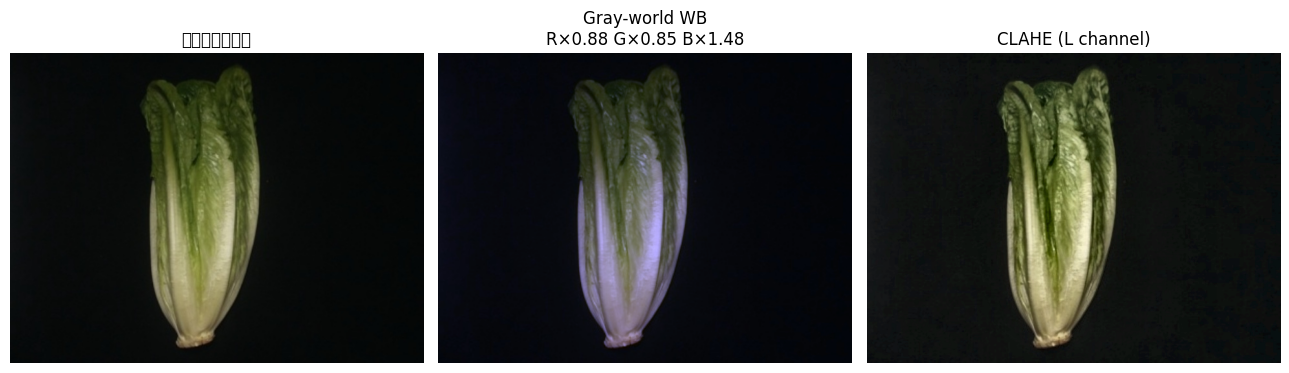

✅ img_bgr, HSV, LAB และทุก channel อัปเดตเป็นภาพที่ normalize แล้ว


In [9]:
# === Method 1: Gray-world White Balance ===
# สมมติว่าค่าเฉลี่ย R, G, B ของภาพควรเท่ากัน (= ค่ากลาง 128)
# ถ้า R เฉลี่ยสูงกว่า G → ภาพออกแดงเกิน → ปรับลด R ลง

r_avg = np.mean(img_bgr[:,:,2][px])
g_avg = np.mean(img_bgr[:,:,1][px])
b_avg = np.mean(img_bgr[:,:,0][px])
gray_avg = (r_avg + g_avg + b_avg) / 3

scale_r = gray_avg / (r_avg + 1e-10)
scale_g = gray_avg / (g_avg + 1e-10)
scale_b = gray_avg / (b_avg + 1e-10)

img_gw = img_bgr.astype(float).copy()
img_gw[:,:,2] = np.clip(img_gw[:,:,2] * scale_r, 0, 255)
img_gw[:,:,1] = np.clip(img_gw[:,:,1] * scale_g, 0, 255)
img_gw[:,:,0] = np.clip(img_gw[:,:,0] * scale_b, 0, 255)
img_gw = img_gw.astype(np.uint8)

print(f"Gray-world scale factors — R:{scale_r:.3f}  G:{scale_g:.3f}  B:{scale_b:.3f}")

# === Method 2: CLAHE บน L channel ของ LAB ===
# ปรับความสว่างเฉพาะพื้นที่ (adaptive) โดยไม่ทำให้สีเพี้ยน

img_lab_norm = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l_ch, a_ch, b_ch2 = cv2.split(img_lab_norm)
clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l_ch)
img_clahe = cv2.cvtColor(cv2.merge([l_clahe, a_ch, b_ch2]), cv2.COLOR_LAB2BGR)

# === เปรียบเทียบภาพ 3 แบบ ===
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(cv2.cvtColor(img_bgr,   cv2.COLOR_BGR2RGB)); axes[0].set_title("ต้นฉบับ");             axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_gw,    cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Gray-world WB\nR×{scale_r:.2f} G×{scale_g:.2f} B×{scale_b:.2f}"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)); axes[2].set_title("CLAHE (L channel)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

# === เลือก method ที่ต้องการ แล้ว re-split channel ใหม่ทั้งหมด ===
img_norm = img_clahe   # ← เปลี่ยนเป็น img_gw ถ้าต้องการใช้ Gray-world

img_bgr  = img_norm    # ทับ img_bgr เพื่อให้ทุก cell ถัดไปใช้ภาพที่ normalize แล้ว
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
b, g, r  = cv2.split(img_bgr)
h, s, v  = cv2.split(img_hsv)
l, a, b_ch = cv2.split(img_lab)
print("✅ img_bgr, HSV, LAB และทุก channel อัปเดตเป็นภาพที่ normalize แล้ว")

## Cell 3 — Color Features (RGB / HSV / LAB) บน plant pixels เท่านั้น

In [10]:
def stats(arr, mask):
    """คำนวณสถิติของ channel บน plant pixels เท่านั้น"""
    d = arr[mask].astype(float)
    return {
        "min":    np.min(d),
        "max":    np.max(d),
        "mean":   np.mean(d).round(2),
        "median": np.median(d).round(2),
        "std":    np.std(d).round(2),
        "IQR":    (np.percentile(d,75) - np.percentile(d,25)).round(2),
        "skew":   round(float(skew(d)), 4),
    }

channels = {
    "R": r, "G": g, "B": b,
    "H": h, "S": s, "V": v,
    "L": l, "a": a, "b_ch": b_ch,
}

print(f"{'Ch':<5}", end="")
for k in ["min","max","mean","median","std","IQR","skew"]:
    print(f"{k:>9}", end="")
print()
print("-" * 68)

for name, ch in channels.items():
    st = stats(ch, px)
    print(f"{name:<5}", end="")
    for k in ["min","max","mean","median","std","IQR","skew"]:
        print(f"{st[k]:>9}", end="")
    print()

Ch         min      max     mean   median      std      IQR     skew
--------------------------------------------------------------------
R          2.0    251.0   116.59    110.0    54.04     86.0   0.3377
G         19.0    247.0   120.25    115.0    49.87     79.0   0.3347
B          0.0    212.0    73.97     65.0    46.69     71.0   0.5765
H          9.0     57.0     32.5     33.0     5.47      9.0   -0.208
S         35.0    255.0   114.72    108.0    45.35     57.0   0.9992
V         19.0    251.0   122.26    116.0    51.18     82.0   0.3316
L         11.0    246.0   123.63    120.0    50.98     81.0   0.2277
a        110.0    136.0   118.87    118.0     4.15      6.0   0.5874
b_ch     132.0    172.0   152.81    153.0     6.31      7.0   0.0721


## Cell 4 — Vegetation Index (ExG, GLI) บน plant pixels

In [11]:
r_f = r.astype(float) / 255
g_f = g.astype(float) / 255
b_f = b.astype(float) / 255

ExG  = 2*g_f - r_f - b_f                                        # Excess Green
ExGR = ExG - 1.4*r_f - g_f                                      # Excess Green minus Red
GLI  = (2*g_f - r_f - b_f) / (2*g_f + r_f + b_f + 1e-6)        # Green Leaf Index
VARI = (g_f - r_f) / (g_f + r_f - b_f + 1e-6)                  # Visible Atmospherically Resistant Index
WI   = (g_f - b_f) / (r_f - g_f + 1e-6)                        # Woebbecke Index — สูง = เหลืองมาก

for name, idx in [("ExG", ExG), ("ExGR", ExGR), ("GLI", GLI), ("VARI", VARI), ("WI", WI)]:
    d = idx[px]
    print(f"{name:<6}  mean:{d.mean():7.4f}  std:{d.std():7.4f}  min:{d.min():8.4f}  max:{d.max():8.4f}")

ExG     mean: 0.1959  std: 0.0663  min: -0.0314  max:  0.4000
ExGR    mean:-0.9158  std: 0.4953  min: -2.2235  max:  0.0675
GLI     mean: 0.1474  std: 0.0927  min: -0.0714  max:  0.9130
VARI    mean: 0.0368  std: 0.0670  min: -0.3125  max:  0.8333
WI      mean:4354.9726  std:29082.7840  min:-83.0212  max:313725.4902


## Cell 5 — Pixel Ratio (Brown / Yellow / Green) บน plant pixels

In [12]:
plant_px_count = np.sum(px)

def pixel_ratio(mask_color):
    """% pixel สีนั้นใน plant area"""
    return np.sum(cv2.bitwise_and(mask_color, plant_mask) > 0) / plant_px_count * 100

mask_brown  = cv2.inRange(img_hsv, np.array([5,  50, 30]),  np.array([20, 255, 200]))
mask_yellow = cv2.inRange(img_hsv, np.array([20, 50, 80]),  np.array([35, 255, 255]))
mask_green  = cv2.inRange(img_hsv, np.array([35, 40, 40]),  np.array([85, 255, 255]))

print(f"Brown  ratio : {pixel_ratio(mask_brown):.2f}%  → รอยเน่า/ช้ำ")
print(f"Yellow ratio : {pixel_ratio(mask_yellow):.2f}%  → ใบแก่/chlorophyll สลาย")
print(f"Green  ratio : {pixel_ratio(mask_green):.2f}%   → ผักสด")

Brown  ratio : 1.26%  → รอยเน่า/ช้ำ
Yellow ratio : 55.94%  → ใบแก่/chlorophyll สลาย
Green  ratio : 41.60%   → ผักสด


## Cell 6 — GLCM Texture Features (Energy, Contrast, Homogeneity, Correlation, Entropy, Dissimilarity, ASM, Skewness, Kurtosis)

In [13]:
from scipy.stats import kurtosis as scipy_kurtosis

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# crop bounding box ของ plant เพื่อลด noise
x, y, w, h_box = cv2.boundingRect(plant_mask)
gray_crop = gray[y:y+h_box, x:x+w]
gray_q = (gray_crop // 16).astype(np.uint8)  # ลด level → 16

glcm = graycomatrix(gray_q,
    distances=[1, 2, 3],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=16, symmetric=True, normed=True)

# --- graycoprops features ---
props = ["energy", "contrast", "homogeneity", "correlation", "dissimilarity", "ASM"]
print(f"{'Property':<16} {'mean':>8} {'std':>8}")
print("-" * 34)
for p in props:
    arr = graycoprops(glcm, p)
    print(f"{p:<16} {arr.mean():>8.4f} {arr.std():>8.4f}")

# --- Entropy (คำนวณจาก GLCM matrix โดยตรง) ---
# Entropy = -sum(P * log2(P)) — สูง = texture ซับซ้อน, ต่ำ = สม่ำเสมอ
glcm_norm = glcm[:, :, :, :]
eps = 1e-10   # กัน log(0)
entropy_vals = -np.sum(glcm_norm * np.log2(glcm_norm + eps), axis=(0, 1))
print(f"{'entropy':<16} {entropy_vals.mean():>8.4f} {entropy_vals.std():>8.4f}")

# --- Skewness & Kurtosis ของ grayscale pixel บน plant ---
gray_plant = gray[px].astype(float)
print(f"\n--- Distribution of grayscale (plant pixels only) ---")
print(f"{'skewness':<16} {float(skew(gray_plant)):>8.4f}   → บวก=ภาพมืดกว่าปกติ, ลบ=สว่างกว่า")
print(f"{'kurtosis':<16} {float(scipy_kurtosis(gray_plant)):>8.4f}   → สูง=มี outlier เยอะ (รอยตำหนิ)")

Property             mean      std
----------------------------------
energy             0.2121   0.0184
contrast           1.2149   0.8383
homogeneity        0.7317   0.0811
correlation        0.9561   0.0304
dissimilarity      0.6395   0.2573
ASM                0.0453   0.0079
entropy            5.4383   0.3896

--- Distribution of grayscale (plant pixels only) ---
skewness           0.3679   → บวก=ภาพมืดกว่าปกติ, ลบ=สว่างกว่า
kurtosis          -0.7811   → สูง=มี outlier เยอะ (รอยตำหนิ)


## Cell 7 — Histogram Bins (การกระจายความสว่างบน plant)

Bin                 range    count    ratio
--------------------------------------------
bin_0               0-32      500   0.0082
bin_1              32-64   10,629   0.1745
bin_2              64-96   14,668   0.2408
bin_3             96-128   11,825   0.1941
bin_4            128-160   10,461   0.1717
bin_5            160-192    7,637   0.1254
bin_6            192-224    4,224   0.0693
bin_7            224-256      977   0.0160


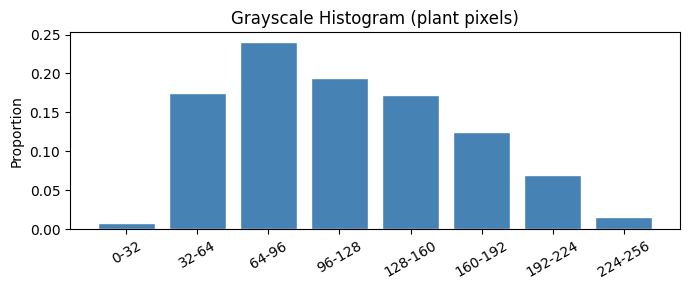

In [14]:
# Histogram bins — แบ่งค่า grayscale เป็น 8 กลุ่ม (0-31, 32-63, ..., 224-255)
# แต่ละ bin บอกว่ามี pixel สว่างน้อย/มาก เท่าไหร่
hist, bin_edges = np.histogram(gray[px], bins=8, range=(0, 256))
hist_norm = hist / np.sum(hist)  # normalize เป็น probability

print(f"{'Bin':<12} {'range':>12} {'count':>8} {'ratio':>8}")
print("-" * 44)
for i, (val, edge) in enumerate(zip(hist_norm, bin_edges)):
    rng = f"{int(bin_edges[i])}-{int(bin_edges[i+1])}"
    print(f"bin_{i:<7} {rng:>12} {hist[i]:>8,} {val:>8.4f}")

# แสดง histogram
plt.figure(figsize=(7, 3))
plt.bar(range(8), hist_norm, color="steelblue", edgecolor="white")
plt.xticks(range(8), [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(8)], rotation=30)
plt.ylabel("Proportion"); plt.title("Grayscale Histogram (plant pixels)")
plt.tight_layout(); plt.show()

## Cell 8 — Edge Density (ความหนาแน่นของขอบ)

Edge density (Canny)  : 20.02%  → สูง=ขอบคม/สด, ต่ำ=เบลอ/เหี่ยว
Laplacian variance    : 160.62   → สูง=ภาพคม, ต่ำ=ภาพเบลอ


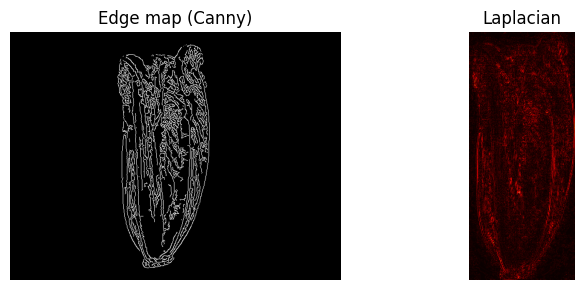

In [15]:
# Edge Density — % pixel ที่เป็นขอบใน plant area
# ใบสด = ขอบคม (edge เยอะ), ใบเหี่ยว = ขอบเบลอ (edge น้อย)

edges = cv2.Canny(gray, threshold1=50, threshold2=150)  # หา edge ด้วย Canny
edges_on_plant = cv2.bitwise_and(edges, plant_mask)      # เอาเฉพาะบน plant

edge_density = np.sum(edges_on_plant > 0) / np.sum(px) * 100

# Laplacian variance — วัดความคมชัดโดยรวม
laplacian = cv2.Laplacian(gray_crop, cv2.CV_64F)
laplacian_var = laplacian.var()

print(f"Edge density (Canny)  : {edge_density:.2f}%  → สูง=ขอบคม/สด, ต่ำ=เบลอ/เหี่ยว")
print(f"Laplacian variance    : {laplacian_var:.2f}   → สูง=ภาพคม, ต่ำ=ภาพเบลอ")

# แสดง edge map
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(edges_on_plant, cmap="gray"); axes[0].set_title("Edge map (Canny)"); axes[0].axis("off")
axes[1].imshow(np.abs(laplacian), cmap="hot"); axes[1].set_title("Laplacian"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Cell 9 — Hu Moments (Shape descriptor)

In [16]:
# Hu Moments — 7 ค่าที่บอกรูปทรงของผัก
# invariant ต่อ rotation/scale/translation — เหมาะสำหรับเปรียบเทียบ shape ต่างภาพ

moments = cv2.moments(plant_mask)
hu = cv2.HuMoments(moments).flatten()

# log transform เพราะค่า Hu มีช่วงกว้างมาก (บางตัว ~1e-20)
hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

print(f"{'Hu Moment':<12} {'raw':>14} {'log-transform':>14}")
print("-" * 42)
for i, (raw, log) in enumerate(zip(hu, hu_log)):
    print(f"hu[{i}]{'':8} {raw:>14.6e} {log:>14.4f}")

Hu Moment               raw  log-transform
------------------------------------------
hu[0]           9.152644e-04         3.0385
hu[1]           4.197127e-07         6.3769
hu[2]           2.330002e-11         9.9090
hu[3]           3.527195e-12         9.9849
hu[4]           2.905058e-23        10.0000
hu[5]           2.063568e-15        10.0000
hu[6]          -1.336113e-23       -10.0000


## Cell 10 — LBP (Local Binary Pattern)

LBP Histogram (uniform, 10 bins) — normalized:
  pattern_0: 0.0167
  pattern_1: 0.0432
  pattern_2: 0.0360
  pattern_3: 0.1376
  pattern_4: 0.2838
  pattern_5: 0.1837
  pattern_6: 0.0609
  pattern_7: 0.0602
  pattern_8: 0.1152
  pattern_9: 0.0629

LBP mean : 4.8551
LBP std  : 2.1421  → สูง = texture หลากหลาย


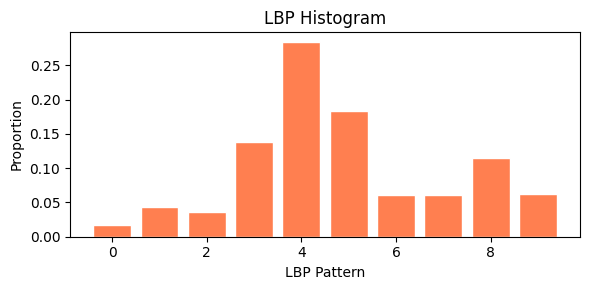

In [17]:
from skimage.feature import local_binary_pattern

# LBP — เปรียบ pixel กับเพื่อนบ้าน 8 ตัว แล้วแปลงเป็นเลขฐานสอง
# radius=1, n_points=8 คือมาตรฐานที่ใช้บ่อยที่สุด
lbp = local_binary_pattern(gray_crop, P=8, R=1, method="uniform")

# สรุปด้วย histogram ของค่า LBP (มี 10 patterns หลักใน uniform mode)
lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10))
lbp_hist_norm = lbp_hist / lbp_hist.sum()

print("LBP Histogram (uniform, 10 bins) — normalized:")
for i, v in enumerate(lbp_hist_norm):
    print(f"  pattern_{i}: {v:.4f}")

print(f"\nLBP mean : {lbp.mean():.4f}")
print(f"LBP std  : {lbp.std():.4f}  → สูง = texture หลากหลาย")

plt.figure(figsize=(6, 3))
plt.bar(range(10), lbp_hist_norm, color="coral", edgecolor="white")
plt.xlabel("LBP Pattern"); plt.ylabel("Proportion")
plt.title("LBP Histogram"); plt.tight_layout(); plt.show()

## Cell 11 — Gabor Filter (Multi-scale Texture)

In [18]:
# Gabor Filter — กรองภาพด้วยความถี่และทิศทางต่างๆ เพื่อดู texture pattern
# ใช้ 3 ความถี่ × 4 ทิศ = 12 combinations

gray_f32 = gray_crop.astype(np.float32) / 255.0

results = []
print(f"{'freq':<8} {'theta':>6} {'mean':>8} {'std':>8}")
print("-" * 34)
for freq in [0.1, 0.2, 0.3]:
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        kernel = cv2.getGaborKernel(
            ksize=(11, 11), sigma=3.0,
            theta=theta, lambd=1.0/freq,
            gamma=0.5, psi=0)
        filtered = cv2.filter2D(gray_f32, cv2.CV_32F, kernel)
        m, st = filtered.mean(), filtered.std()
        results.append((freq, theta, m, st))
        print(f"{freq:<8.1f} {np.degrees(theta):>6.0f}° {m:>8.4f} {st:>8.4f}")

freq      theta     mean      std
----------------------------------
0.1           0°   5.0883   3.8236
0.1          45°   8.0336   5.0797
0.1          90°   5.0922   3.2277
0.1         135°   8.0336   5.1233
0.2           0°   0.2056   0.5481
0.2          45°   0.6165   0.4439
0.2          90°   0.2068   0.2329
0.2         135°   0.6165   0.4901
0.3           0°  -0.4924   0.3350
0.3          45°   0.2150   0.1496
0.3          90°  -0.4918   0.3075
0.3         135°   0.2150   0.1596


## Cell 12 — FFT (Frequency Analysis)

Low-freq energy  : 7.42e+13
High-freq energy : 1.68e+11
High/Low ratio   : 0.0023  → สูง=ขอบคม/สด, ต่ำ=เบลอ/เหี่ยว


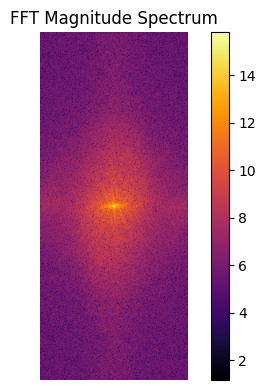

In [19]:
# FFT — แปลงภาพเป็น frequency domain
# ผักสด = มี high-frequency เยอะ (ขอบใบคม, เส้นใบชัด)
# ผักเหี่ยว = high-frequency ลด (ภาพเบลอ, ขอบนุ่ม)

fft = np.fft.fft2(gray_crop)
fft_shift = np.fft.fftshift(fft)         # เลื่อน DC component มาตรงกลาง
magnitude = np.abs(fft_shift)
log_magnitude = np.log1p(magnitude)      # log scale ให้มองเห็นง่ายขึ้น

# แบ่ง high/low frequency โดยดูจากระยะห่างจากจุดกลาง
cy, cx = gray_crop.shape[0]//2, gray_crop.shape[1]//2
Y, X = np.ogrid[:gray_crop.shape[0], :gray_crop.shape[1]]
dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
radius = min(cy, cx)

low_freq_energy  = np.sum(magnitude[dist < radius*0.1]**2)
high_freq_energy = np.sum(magnitude[dist > radius*0.5]**2)
ratio = high_freq_energy / (low_freq_energy + 1e-10)

print(f"Low-freq energy  : {low_freq_energy:.2e}")
print(f"High-freq energy : {high_freq_energy:.2e}")
print(f"High/Low ratio   : {ratio:.4f}  → สูง=ขอบคม/สด, ต่ำ=เบลอ/เหี่ยว")

plt.figure(figsize=(5, 4))
plt.imshow(log_magnitude, cmap="inferno")
plt.colorbar(); plt.title("FFT Magnitude Spectrum"); plt.axis("off")
plt.tight_layout(); plt.show()

## Cell 13 — Shape Features (Area, Perimeter, Circularity, Solidity, Extent, Aspect Ratio, Eccentricity, Compactness)

Feature                   Value  หมายเหตุ
------------------------------------------------------------
Area                     60,601  px
Perimeter               1169.98  px
Circularity              0.5563  ใกล้ 1.0 = กลม
Solidity                 0.9456  ใกล้ 1.0 = ขอบสมบูรณ์ ไม่หัก
Extent                   0.7530  สัดส่วนเต็ม bounding box
Aspect Ratio             0.4174  > 1 = ยาวกว่ากว้าง
Eccentricity                nan  0=กลม, 1=เป็นเส้น
Compactness             22.5880  สูง = ขอบขรุขระ/ยุ่ง


C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3020307414.py:24: RuntimeWarning: invalid value encountered in sqrt
  eccentricity  = np.sqrt(1 - (ma / (MA + 1e-10))**2)  # 0=วงกลม, 1=เส้นตรง
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3020307414.py:46: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3020307414.py:46: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3020307414.py:46: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\3020307414.py:46: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\kbbos\AppData\Local\Temp\ipykernel_21556\30203

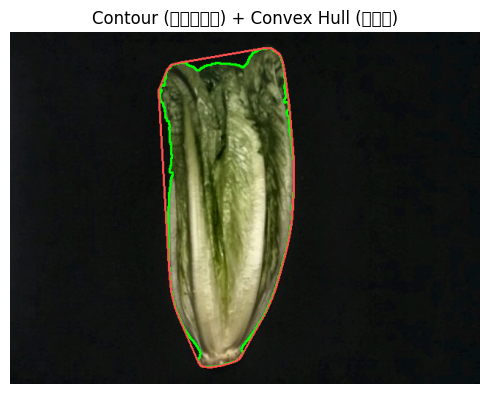

In [20]:
# หา contour ใหญ่สุด = ตัวผัก
contours, _ = cv2.findContours(plant_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)  # เอา contour ที่ใหญ่สุด

# --- Area & Perimeter ---
area      = cv2.contourArea(cnt)                          # จำนวน pixel ในผัก
perimeter = cv2.arcLength(cnt, closed=True)               # ความยาวเส้นขอบ

# --- Circularity: 4πA / P² → 1.0 = วงกลมสมบูรณ์ ---
circularity = (4 * np.pi * area) / (perimeter ** 2 + 1e-10)

# --- Solidity: A / A_convex_hull → ใบเสีย/หัก = ลดลง ---
hull        = cv2.convexHull(cnt)
hull_area   = cv2.contourArea(hull)
solidity    = area / (hull_area + 1e-10)

# --- Extent: A / A_bounding_box ---
_, _, bw, bh = cv2.boundingRect(cnt)
extent      = area / (bw * bh + 1e-10)

# --- Aspect Ratio, Eccentricity จาก Ellipse fit ---
(cx, cy_e), (MA, ma), angle = cv2.fitEllipse(cnt)  # MA=major axis, ma=minor axis
aspect_ratio  = MA / (ma + 1e-10)
eccentricity  = np.sqrt(1 - (ma / (MA + 1e-10))**2)  # 0=วงกลม, 1=เส้นตรง

# --- Compactness: P² / A → ขอบยุ่ง = สูง ---
compactness = (perimeter ** 2) / (area + 1e-10)

print(f"{'Feature':<18} {'Value':>12}  {'หมายเหตุ'}")
print("-" * 60)
print(f"{'Area':<18} {area:>12,.0f}  px")
print(f"{'Perimeter':<18} {perimeter:>12.2f}  px")
print(f"{'Circularity':<18} {circularity:>12.4f}  ใกล้ 1.0 = กลม")
print(f"{'Solidity':<18} {solidity:>12.4f}  ใกล้ 1.0 = ขอบสมบูรณ์ ไม่หัก")
print(f"{'Extent':<18} {extent:>12.4f}  สัดส่วนเต็ม bounding box")
print(f"{'Aspect Ratio':<18} {aspect_ratio:>12.4f}  > 1 = ยาวกว่ากว้าง")
print(f"{'Eccentricity':<18} {eccentricity:>12.4f}  0=กลม, 1=เป็นเส้น")
print(f"{'Compactness':<18} {compactness:>12.4f}  สูง = ขอบขรุขระ/ยุ่ง")

# แสดง contour + convex hull บนภาพ
vis = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
cv2.drawContours(vis, [cnt],  -1, (0, 255, 0), 2)   # contour = เขียว
cv2.drawContours(vis, [hull], -1, (255, 80, 80), 2)  # convex hull = แดง
plt.figure(figsize=(5, 6))
plt.imshow(vis); plt.title("Contour (เขียว) + Convex Hull (แดง)"); plt.axis("off")
plt.tight_layout(); plt.show()

## Cell 14 — Edge Browning Ratio + Dark Spots

In [21]:
# === Edge Browning Ratio ===
# สร้าง "edge zone" = บริเวณขอบใบ โดย erode mask เข้ามาแล้วเอาส่วนต่าง
edge_thickness = 20  # pixel — ความหนาของ "ขอบใบ" ที่จะตรวจ

kernel = np.ones((edge_thickness*2+1, edge_thickness*2+1), np.uint8)
inner_mask  = cv2.erode(plant_mask, kernel, iterations=1)   # mask ที่ถูก erode เข้ามา
edge_zone   = cv2.subtract(plant_mask, inner_mask)          # ขอบใบ = ผัก - ส่วนใน

# นับ brown pixel ที่อยู่ในขอบใบเท่านั้น
brown_on_edge = cv2.bitwise_and(mask_brown, edge_zone)
edge_zone_px  = np.sum(edge_zone > 0)

edge_browning_ratio = np.sum(brown_on_edge > 0) / (edge_zone_px + 1e-10) * 100

print(f"Edge zone pixels     : {edge_zone_px:,}")
print(f"Edge browning ratio  : {edge_browning_ratio:.2f}%  → สูง = tip burn / ขอบใบไหม้")

# แสดง edge zone บนภาพ
vis_edge = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
vis_edge[edge_zone > 0] = [255, 200, 0]       # ขอบใบ = เหลือง
vis_edge[brown_on_edge > 0] = [255, 50, 50]   # brown บนขอบ = แดง

# === Dark Spots ===
# dark spot = บริเวณมืดผิดปกติบนผัก (เน่า, ช้ำ, จุดดำ)
# ใช้ V channel — pixel ที่มืดกว่าค่าเฉลี่ย plant มากๆ คือ dark spot
v_plant_mean = np.mean(v[px])
dark_thresh  = max(int(v_plant_mean * 0.4), 20)  # threshold = 40% ของค่าเฉลี่ย

dark_mask_raw = np.zeros_like(plant_mask)
dark_mask_raw[(v < dark_thresh) & px] = 255       # pixel มืดบน plant

# กำจัด noise ด้วย morphological opening
kernel_small = np.ones((3, 3), np.uint8)
dark_mask_clean = cv2.morphologyEx(dark_mask_raw, cv2.MORPH_OPEN, kernel_small)

# นับ connected components = นับจำนวน "จุด" แยกกัน
num_labels, labels, stats_cc, _ = cv2.connectedComponentsWithStats(dark_mask_clean)
min_spot_size = 20  # กรอง noise — spot ต้องใหญ่กว่า 20 px
dark_spots = [s for s in stats_cc[1:] if s[cv2.CC_STAT_AREA] >= min_spot_size]

dark_spot_count = len(dark_spots)
dark_spot_area  = sum(s[cv2.CC_STAT_AREA] for s in dark_spots)
dark_spot_ratio = dark_spot_area / (np.sum(px) + 1e-10) * 100

print(f"\nDark spot count      : {dark_spot_count}  → เยอะ = มีรอยเน่า/ช้ำหลายจุด")
print(f"Dark spot area ratio : {dark_spot_ratio:.2f}%")

# แสดงภาพรวม
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(vis_edge);                                     axes[0].set_title(f"Edge Browning Zone\n(เหลือง=ขอบใบ, แดง=brown) {edge_browning_ratio:.1f}%"); axes[0].axis("off")
axes[1].imshow(dark_mask_clean, cmap="gray");                 axes[1].set_title("Dark Spot Mask"); axes[1].axis("off")
vis_spots = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
for s in dark_spots:
    x0,y0,w0,h0 = s[cv2.CC_STAT_LEFT], s[cv2.CC_STAT_TOP], s[cv2.CC_STAT_WIDTH], s[cv2.CC_STAT_HEIGHT]
    cv2.rectangle(vis_spots, (x0,y0), (x0+w0,y0+h0), (255,50,50), 2)
axes[2].imshow(vis_spots);                                    axes[2].set_title(f"Dark Spots detected: {dark_spot_count}"); axes[2].axis("off")
plt.tight_layout(); plt.show()

Edge zone pixels     : 26,485
Edge browning ratio  : 2.89%  → สูง = tip burn / ขอบใบไหม้


IndexError: invalid index to scalar variable.

## Cell 15 — Specular Highlight (ความมันวาวของใบ)

In [ ]:
# Specular Highlight — ใบสดมี "shine" สะท้อนแสง, ใบเหี่ยวผิวด้านไม่มี
# วัดจาก V channel (ความสว่าง) บน plant pixels เท่านั้น

v_plant = v[px].astype(float)
v_mean  = np.mean(v_plant)
v_max   = np.max(v_plant)
v_std   = np.std(v_plant)

# Specular score = V_max - V_mean — ยิ่งสูง = มี highlight สว่างมาก = ใบสด
specular_score = v_max - v_mean

# % pixel ที่สว่างมากผิดปกติ (top 5% ของ V range) = highlight area
highlight_thresh = np.percentile(v_plant, 95)
highlight_mask = np.zeros_like(plant_mask)
highlight_mask[(v >= highlight_thresh) & px] = 255
highlight_ratio = np.sum(highlight_mask > 0) / np.sum(px) * 100

print(f"V mean (plant)       : {v_mean:.2f}")
print(f"V max  (plant)       : {v_max:.2f}")
print(f"V std  (plant)       : {v_std:.2f}")
print(f"Specular score       : {specular_score:.2f}  → สูง = ใบสดมีมัน, ต่ำ = ใบเหี่ยวผิวด้าน")
print(f"Highlight area ratio : {highlight_ratio:.2f}%  → % พื้นที่สว่างจัด (shine spot)")

# แสดง highlight บนภาพ
vis_hl = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
vis_hl[highlight_mask > 0] = [255, 255, 100]   # highlight = เหลืองสว่าง

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(vis_hl)
axes[0].set_title(f"Highlight zone (top 5% brightness)\nScore: {specular_score:.1f}  Area: {highlight_ratio:.1f}%")
axes[0].axis("off")
axes[1].hist(v_plant, bins=50, color="steelblue", edgecolor="none")
axes[1].axvline(highlight_thresh, color="red", linestyle="--", label=f"95th percentile = {highlight_thresh:.0f}")
axes[1].axvline(v_mean, color="orange", linestyle="--", label=f"mean = {v_mean:.0f}")
axes[1].set_xlabel("V value"); axes[1].set_ylabel("Pixel count")
axes[1].set_title("V channel distribution (plant)"); axes[1].legend()
plt.tight_layout(); plt.show()

## Cell 17 — NGRDI (Normalized Green-Red Difference Index)

In [ ]:
# NGRDI = (G - R) / (G + R) — Normalized Green-Red Difference Index
# ง่ายแต่ sensitive มาก — ใบสดเขียว → G > R → ค่าบวก
# ใบเหลือง/เหี่ยว → R เพิ่มขึ้น G ลด → ค่าลดลง/ติดลบ

NGRDI = (g_f - r_f) / (g_f + r_f + 1e-6)  # -1.0 ถึง +1.0

d = NGRDI[px]
print(f"NGRDI mean   : {d.mean():.4f}  → บวก = เขียวสด, ลบ = เหลือง/แดง")
print(f"NGRDI std    : {d.std():.4f}   → สูง = สีกระจาย ไม่สม่ำเสมอ")
print(f"NGRDI median : {np.median(d):.4f}")
print(f"NGRDI min    : {d.min():.4f}")
print(f"NGRDI max    : {d.max():.4f}")

# แสดง NGRDI map บนภาพ (สีน้ำเงิน=ต่ำ/เหลือง, สีเหลือง=สูง/เขียว)
ngrdi_vis = NGRDI.copy()
ngrdi_vis[~px] = np.nan   # ซ่อน background

plt.figure(figsize=(6, 5))
im = plt.imshow(ngrdi_vis, cmap="RdYlGn", vmin=-0.3, vmax=0.3)
plt.colorbar(im, label="NGRDI value")
plt.title(f"NGRDI Map  (mean={d.mean():.3f})\nแดง=เหลือง/ตำหนิ  เขียว=ใบสด")
plt.axis("off"); plt.tight_layout(); plt.show()

## Cell 18 — Convexity Defects (รอยหยักขอบใบ)

In [ ]:
# Convexity Defects — หารอยหยักหรือหักของขอบใบ
# defect = ส่วนที่ขอบใบ "เว้าเข้าไป" จาก convex hull
# ใบสมบูรณ์ = defect น้อย, ใบฉีกขาด/หัก = defect เยอะและลึก

hull_idx = cv2.convexHull(cnt, returnPoints=False)  # ต้องการ index ไม่ใช่ point
defects  = cv2.convexityDefects(cnt, hull_idx)      # หา defect ทั้งหมด

if defects is not None:
    # defects shape = (N, 1, 4) — [start, end, far_point, depth*256]
    depths = defects[:, 0, 3] / 256.0   # แปลง depth เป็น pixel จริง

    # กรองเฉพาะ defect ที่ลึกพอ (> 5px) เพื่อตัด noise
    sig_defects = depths[depths > 5]

    defect_count    = len(sig_defects)
    defect_depth_mean = sig_defects.mean() if len(sig_defects) > 0 else 0
    defect_depth_max  = sig_defects.max()  if len(sig_defects) > 0 else 0

    # Roughness index = Perimeter จริง / Perimeter ของ convex hull
    hull_perimeter = cv2.arcLength(hull, closed=True)
    roughness_index = perimeter / (hull_perimeter + 1e-10)
else:
    defect_count = defect_depth_mean = defect_depth_max = 0
    roughness_index = 1.0

print(f"Convexity defects (>5px) : {defect_count}      → เยอะ = ขอบใบหยัก/ฉีก")
print(f"Defect depth mean        : {defect_depth_mean:.2f} px")
print(f"Defect depth max         : {defect_depth_max:.2f} px  → ลึก = รอยหักใหญ่")
print(f"Roughness index          : {roughness_index:.4f}  → > 1.0 = ขอบขรุขระ")

# แสดง defect บนภาพ
vis_def = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
cv2.drawContours(vis_def, [hull], -1, (100, 200, 100), 2)  # convex hull = เขียว

if defects is not None:
    for d_item in defects:
        s, e, f, depth = d_item[0]
        if depth / 256.0 > 5:
            far = tuple(cnt[f][0])
            cv2.circle(vis_def, far, 5, (255, 50, 50), -1)   # จุดลึกสุดของ defect = แดง

plt.figure(figsize=(5, 6))
plt.imshow(vis_def)
plt.title(f"Convexity Defects: {defect_count}  Roughness: {roughness_index:.3f}\n(แดง = รอยหยักที่ลึก > 5px)")
plt.axis("off"); plt.tight_layout(); plt.show()

## Cell 19 — Wavelet Features (Multi-scale Texture)

In [ ]:
import pywt  # PyWavelets — pip install PyWavelets ถ้ายังไม่มี

# Wavelet decomposition — แตก texture ออกเป็นหลาย scale พร้อมกัน
# ใช้ Haar wavelet (ง่าย เร็ว เหมาะกับ texture ใบไม้)
# Level 3 = ดู texture 3 ขนาด: ละเอียด, กลาง, หยาบ

coeffs = pywt.wavedec2(gray_crop.astype(float), wavelet="haar", level=3)
# coeffs[0]    = approximation (ภาพโดยรวม)
# coeffs[1..3] = (cH, cV, cD) ที่แต่ละ level
#   cH = horizontal detail (เส้นแนวนอน)
#   cV = vertical detail   (เส้นแนวตั้ง)
#   cD = diagonal detail   (เส้นทแยง)

print(f"{'Level':<8} {'Sub-band':<12} {'Energy':>10} {'Mean':>8} {'Std':>8}")
print("-" * 50)

wavelet_features = {}
for level_idx, detail in enumerate(coeffs[1:], start=1):
    cH, cV, cD = detail
    for name, coef in [("cH", cH), ("cV", cV), ("cD", cD)]:
        energy = np.sum(coef**2) / coef.size   # energy = mean square
        mean   = np.mean(np.abs(coef))
        std    = np.std(coef)
        key    = f"L{level_idx}_{name}"
        wavelet_features[key] = {"energy": energy, "mean": mean, "std": std}
        print(f"Level {level_idx:<3} {name:<12} {energy:>10.4f} {mean:>8.4f} {std:>8.4f}")

# Approximation coefficients (ภาพโดยรวม)
cA = coeffs[0]
print(f"\nApprox (L3) energy : {np.sum(cA**2)/cA.size:.4f}  mean : {np.mean(np.abs(cA)):.4f}")

# แสดง wavelet sub-bands ของ level 1
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
cH1, cV1, cD1 = coeffs[1]
for ax, data, title in zip(axes,
    [np.abs(coeffs[0]), np.abs(cH1), np.abs(cV1), np.abs(cD1)],
    ["Approximation", "L1 Horizontal", "L1 Vertical", "L1 Diagonal"]):
    ax.imshow(data, cmap="gray"); ax.set_title(title); ax.axis("off")
plt.suptitle("Haar Wavelet — Level 1 Sub-bands")
plt.tight_layout(); plt.show()